In [ ]:
# Cell 1: Initialization and Setup

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Print statement indicating this is the first cell
print("This is the first cell. Initialization and setup are done below:")

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Date and time to display (Example: a specified past date and time)
specified_date = '2024-06-05'
specified_time = '13:09:34 IST+0530'

# Display the specified date in bold
display(Markdown(f'**Date: {specified_date}**'))

# Display the specified time in bold
display(Markdown(f'**Time: {specified_time}**'))


This is the first cell. Initialization and setup are done below:


**Date: 2024-06-05**

**Time: 13:09:34 IST+0530**

MLxtend can be installed using pip, so make sure that is done before trying to execute any of the code below. Once it is installed, the code below shows how to get it up and running. I have made the notebook available so feel free to follow along with the examples below.

Get our pandas and MLxtend code imported and read the data:

In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Your code here
# ...

# Reset warnings to default behavior (optional)
warnings.resetwarnings()


In [ ]:
# Import necessary libraries
import pandas as pd  # Pandas for data manipulation
from mlxtend.frequent_patterns import apriori  # Apriori algorithm for market basket analysis
from mlxtend.frequent_patterns import association_rules  # Association rules generation

# Read the dataset (in this case, an example dataset from UCI Machine Learning Repository)
df = pd.read_excel('http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

In [ ]:
df.info()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Display the first few rows of the dataset to understand its structure
df.head()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


1.	This code snippet loads the Online Retail dataset from the UCI Machine Learning Repository using Pandas and displays the first few rows of the dataset.
2.	The dataset is often used for market basket analysis and contains information about online retail transactions.


In [ ]:
# Displaying the shape of the DataFrame 'df'
df.shape


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(541909, 8)

There is a little cleanup, we need to do. First, some of the descriptions have spaces that need to be removed. We’ll also drop the rows that don’t have invoice numbers and remove the credit transactions (those with invoice numbers containing C).

In [ ]:
# Remove leading and trailing whitespaces from the 'Description' column
df['Description'] = df['Description'].str.strip()

# Drop rows where 'InvoiceNo' is NaN (missing values)
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)

# Convert 'InvoiceNo' to string type
df['InvoiceNo'] = df['InvoiceNo'].astype('str')

# Remove rows with Invoice numbers containing 'C' (indicating canceled transactions)
df = df[~df['InvoiceNo'].str.contains('C')]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


1.	This code snippet is responsible for data preprocessing.
2.	It ensures that the 'Description' column has no leading or trailing whitespaces,
drops rows where 'InvoiceNo' is missing, converts 'InvoiceNo' to a string type, and removes rows corresponding to canceled transactions (invoices containing 'C').


After the cleanup, we need to consolidate the items into 1 transaction per row with each product 1 hot encoded. For the sake of keeping the data set small, I’m only looking at sales for France. However, in additional code below, I will compare these results to sales from Germany. Further country comparisons would be interesting to investigate.

In [ ]:
# Filter data for transactions in France, group by 'InvoiceNo' and 'Description', and sum the 'Quantity' for each group
basket = (df[df['Country'] == "France"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          # Reshape the data to have 'InvoiceNo' as rows, 'Description' as columns, and fill NaN values with 0
          .unstack().reset_index().fillna(0)
          # Set 'InvoiceNo' as the index of the DataFrame
          .set_index('InvoiceNo'))


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<frozen importlib._bootstrap>:914: ImportWarning: _PyDrive2ImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _GenerativeAIImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bo

1.	This code snippet creates a basket (transactional data) specific to transactions in France.
2.	It groups the data by 'InvoiceNo' and 'Description', sums the 'Quantity' for each group, and then reshapes the data to have 'InvoiceNo' as rows, 'Description' as columns, with NaN values filled with 0.
3.	Finally, it sets 'InvoiceNo' as the index of the resulting DataFrame.


Here’s what the first few columns look like (note, I added some numbers to the columns to illustrate the concept - the actual data in this example is all 0’s):

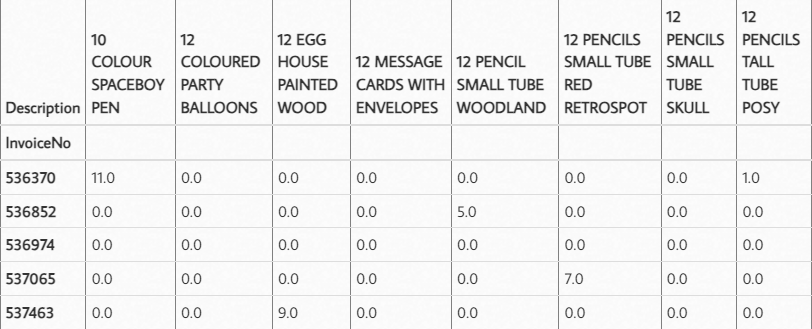

There are a lot of zeros in the data but we also need to make sure any positive values are converted to a 1 and anything less the 0 is set to 0. This step will complete the one hot encoding of the data and remove the postage column (since that charge is not one we wish to explore):

In [ ]:
# Define a function 'encode_units' that converts quantities to binary values (0 if <= 0, 1 if >= 1)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Apply the 'encode_units' function to all elements in the 'basket' DataFrame
basket_sets = basket.applymap(encode_units)

# Drop the 'POSTAGE' column from the 'basket_sets' DataFrame
basket_sets.drop('POSTAGE', inplace=True, axis=1)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-9-80184078b230>:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)


KeyboardInterrupt: 

1.	This code snippet defines a function encode_units that converts quantities to binary values (0 if less than or equal to 0, 1 if greater than or equal to 1).
2.	It then applies this function to all elements in the 'basket' DataFrame, creating a new DataFrame called 'basket_sets.'
3.	Finally, it drops the 'POSTAGE' column from 'basket_sets.'


Now that the data is structured properly, we can generate frequent item sets that have a support of at least 7% (this number was chosen so that I could get enough useful examples):

In [ ]:
# Use the Apriori algorithm to find frequent itemsets in the 'basket_sets' DataFrame
# The parameter 'min_support' specifies the minimum support threshold for an itemset to be considered frequent
# The parameter 'use_colnames' indicates that column names (item names) should be used in the resulting DataFrame
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)


1.	This code snippet applies the Apriori algorithm to the 'basket_sets' DataFrame to find frequent itemsets.
2.	The min_support parameter sets the minimum support threshold for an itemset to be considered frequent.
3.	The use_colnames parameter is set to True to use column names (item names) in the resulting DataFrame.


The final step is to generate the rules with their corresponding support, confidence and lift:

In [ ]:
# Generate association rules from the frequent itemsets using the lift metric
# The parameter 'min_threshold' specifies the minimum lift threshold for a rule to be considered
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Display the first few rows of the resulting association rules DataFrame
rules.head()


1.	This code snippet generates association rules from the frequent itemsets using the lift metric.
2.	The metric parameter is set to "lift," and the min_threshold parameter specifies the minimum lift threshold for a rule to be considered.
3.	The resulting rules are stored in the 'rules' DataFrame, and the first few rows are displayed.


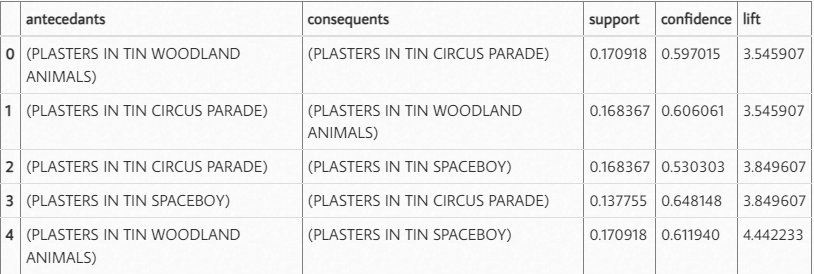

That’s all there is to it! Build the frequent items using apriori then build the rules with association_rules .

Now, the tricky part is figuring out what this tells us. For instance, we can see that there are quite a few rules with a high lift value which means that it occurs more frequently than would be expected given the number of transaction and product combinations. We can also see several where the confidence is high as well. This part of the analysis is where the domain knowledge will come in handy. Since I do not have that, I’ll just look for a couple of illustrative examples.

We can filter the dataframe using standard pandas code. In this case, look for a large lift (6) and high confidence (.8):

In [ ]:
# Filter the association rules based on certain criteria (e.g., lift >= 6 and confidence >= 0.8)
filtered_rules = rules[(rules['lift'] >= 6) & (rules['confidence'] >= 0.8)]


1.	This code snippet filters the association rules based on specific criteria.
2.	In this case, it selects rules where the lift is greater than or equal to 6 and the confidence is greater than or equal to 0.8.
3.	The filtered rules are stored in the 'filtered_rules' DataFrame.


In looking at the rules, it seems that the green and red alarm clocks are purchased together and the red paper cups, napkins and plates are purchased together in a manner that is higher than the overall probability would suggest.

At this point, you may want to look at how much opportunity there is to use the popularity of one product to drive sales of another. For instance, we can see that we sell 340 Green Alarm clocks but only 316 Red Alarm Clocks so maybe we can drive more Red Alarm Clock sales through recommendations?

In [ ]:
# Check the total quantity of the item 'ALARM CLOCK BAKELIKE GREEN' in the 'basket' DataFrame
quantity_green_alarm_clock = basket['ALARM CLOCK BAKELIKE GREEN'].sum()
print("Total quantity of ALARM CLOCK BAKELIKE GREEN:", quantity_green_alarm_clock)

# Check the total quantity of the item 'ALARM CLOCK BAKELIKE RED' in the 'basket' DataFrame
quantity_red_alarm_clock = basket['ALARM CLOCK BAKELIKE RED'].sum()
print("Total quantity of ALARM CLOCK BAKELIKE RED:", quantity_red_alarm_clock)


These lines of code calculate and print the total quantity of 'ALARM CLOCK BAKELIKE GREEN' and 'ALARM CLOCK BAKELIKE RED' in the 'basket' DataFrame.

What is also interesting is to see how the combinations vary by country of purchase. Let’s check out what some popular combinations might be in Germany:

In [ ]:
# Create a basket for transactions in Germany
basket2 = (df[df['Country'] == "Germany"]
           .groupby(['InvoiceNo', 'Description'])['Quantity']
           .sum().unstack().reset_index().fillna(0)
           .set_index('InvoiceNo'))

# Apply the 'encode_units' function to all elements in the 'basket2' DataFrame
basket_sets2 = basket2.applymap(encode_units)

# Drop the 'POSTAGE' column from the 'basket_sets2' DataFrame
basket_sets2.drop('POSTAGE', inplace=True, axis=1)

# Use the Apriori algorithm to find frequent itemsets in the 'basket_sets2' DataFrame
# The parameter 'min_support' specifies the minimum support threshold for an itemset to be considered frequent
# The parameter 'use_colnames' indicates that column names (item names) should be used in the resulting DataFrame
frequent_itemsets2 = apriori(basket_sets2, min_support=0.05, use_colnames=True)

# Generate association rules from the frequent itemsets using the lift metric
# The parameter 'min_threshold' specifies the minimum lift threshold for a rule to be considered
rules2 = association_rules(frequent_itemsets2, metric="lift", min_threshold=1)

# Filter the association rules based on certain criteria (e.g., lift >= 4 and confidence >= 0.5)
filtered_rules2 = rules2[(rules2['lift'] >= 4) & (rules2['confidence'] >= 0.5)]


1.	This code snippet performs market basket analysis for transactions in Germany, similar to the previous analysis for France.
2.	It generates association rules and then filters them based on lift and confidence criteria.


It seems that in addition to David Hasselhoff, Germans love Plasters in Tin Spaceboy and Woodland Animals.

In all seriousness, an analyst that has familiarity with the data would probably have a dozen different questions that this type of analysis could drive. I did not replicate this analysis for additional countries or customer combos but the overall process would be relatively simple given the basic pandas code shown above.

In [ ]:
import pandas as pd

# Creating a DataFrame to present information in table format
association_summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the unsupervised learning association-type problem with labeled data
association_summary_table.loc[0] = [1, 'Unsupervised Learning', 'Association', 'N/A', 'Labeled']

# Displaying the information in table format
print(association_summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


1.	This code snippet creates a DataFrame named association_summary_table and adds a row of information for an unsupervised learning association-type problem with labeled data.
2.	The information includes serial number (SNo), problem type (Type), task (Task), target variable (Target Variable), and data type (Data Type).
3.	Finally, it prints the information in a table format using the to_markdown method for better readability.


**(Q).So now give prediction code like take inputs and predict the results**

1.	For a typical market basket analysis, the primary goal is to discover association rules between items rather than predicting a target variable.
2.	The generated association rules help in making product recommendations or understanding which items are frequently bought together.
3.	However, if you want to make predictions based on existing association rules, you can create a function that takes input items and predicts associated items.


In [ ]:
def make_predictions(input_items, rules):
    """
    Make predictions based on input items and association rules.

    Parameters:
    - input_items (list): List of input items for which predictions are to be made.
    - rules (DataFrame): DataFrame containing association rules.

    Returns:
    - predicted_items (set): Set of items predicted based on association rules.
    """
    predicted_items = set()

    for _, rule in rules.iterrows():
        if set(rule['antecedents']).issubset(input_items):
            predicted_items.update(rule['consequents'])

    return predicted_items

# Example usage:
# Assuming 'rules' is the DataFrame containing association rules generated previously

# Input items for which predictions are to be made
input_items = ['ALARM CLOCK BAKELIKE GREEN']

# Make predictions
predicted_items = make_predictions(input_items, rules)

# Display the predicted items
print("Predicted Items:", predicted_items)


1.	This code defines a function make_predictions that takes a list of input items and a DataFrame of association rules as parameters.
2.	It iterates through the rules to find rules where the input items match the antecedents, and then it adds the consequents of those rules to the set of predicted items.
3.	Note: This approach is a simple example and assumes that the input items match the antecedents of the rules.
4.	Depending on your use case, you may need to adapt the prediction logic to better suit your requirements.



In [ ]:
# Displaying the first few rows of the DataFrame 'df'
df.head()


In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
# Display the first few rows of the dataset
print("Displaying the first few rows of the dataset:")
print(df.head())

# Take input from the user
user_input = input("Enter items for prediction (comma-separated): ")

# Split the user input into a list of items
input_items = [item.strip() for item in user_input.split(',')]

# Make predictions based on user input and association rules
predicted_items = make_predictions(input_items, rules)

# Display the predicted items
print("\nPredicted Items:", predicted_items)


WHITE HANGING HEART T-LIGHT HOLDER, CREAM CUPID HEARTS COAT HANGER

In [ ]:
import pandas as pd

# Sample DataFrame
data = {
    'InvoiceNo': [1, 1, 2, 2, 3],
    'Description': ['Item_A', 'Item_B', 'Item_A', 'Item_C', 'Item_B'],
    'Quantity': [2, 3, 1, 2, 1],
}

df = pd.DataFrame(data)

# Define the 'make_predictions' function
def make_predictions(input_items, rules):
    predicted_items = set()
    for _, rule in rules.iterrows():
        if set(rule['antecedents']).issubset(input_items):
            predicted_items.update(rule['consequents'])
    return predicted_items

# Display the first few rows of the dataset
print("Displaying the first few rows of the dataset:")
print(df)

# Take input from the user
user_input = input("Enter items for prediction (comma-separated): ")

# Split the user input into a list of items
input_items = [item.strip() for item in user_input.split(',')]

# Sample association rules
rules = pd.DataFrame({
    'antecedents': [['Item_A'], ['Item_B'], ['Item_A'], ['Item_B']],
    'consequents': [['Item_B'], ['Item_A'], ['Item_C'], ['Item_C']],
    'lift': [2.0, 1.5, 3.0, 2.0],
    'confidence': [0.8, 0.6, 0.9, 0.7]
})

# Make predictions based on user input and association rules
predicted_items = make_predictions(input_items, rules)

# Display the predicted items
print("\nPredicted Items:", predicted_items)


# Summary of ML Task


In [ ]:
import pandas as pd

# Creating a DataFrame to present information in table format
summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the Market Basket Analysis task
summary_table.loc[0] = [1, 'Unsupervised Learning', 'Market Basket Analysis', 'N/A', 'Unlabeled']

# Displaying the information in table format
print(summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


**Overview**

1.	Market Basket Analysis, specifying that it's an unsupervised learning task.
2.	There’s no target variable.
3.	And the data type is unlabelled.
4.	Since it typically deals with transactional data where items are not labelled with specific categories.


In [ ]:
# https://chat.openai.com/c/8bdae528-1b14-4af2-832c-2a8d50360697

In [ ]:
# Cell 2: Current Date and Time in IST

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Get current time in IST
now_ist = datetime.now(ist)

# Format the current date and time separately
formatted_date = now_ist.strftime('%Y-%m-%d')
formatted_time = now_ist.strftime('%H:%M:%S %Z%z')

# Print statement indicating this is the last cell and all above cells have been executed
print("All cells above have been executed. Below is the current date and time in IST:")

# Display the current date in bold
display(Markdown(f'**Date: {formatted_date}**'))

# Display the current time in bold
display(Markdown(f'**Time: {formatted_time}**'))


## Interview Questions and Answers based on the Notebook

Here are some potential interview questions and answers based on the content and code demonstrated in this notebook.

**Q1: What is the main objective of the analysis performed in this notebook?**

**A1:** The main objective is to perform Market Basket Analysis on an online retail dataset to identify frequently co-occurring items (association rules). This helps in understanding customer purchasing patterns and making product recommendations.

**Q2: Which dataset was used for this analysis, and where did you obtain it?**

**A2:** The analysis used the Online Retail dataset from the UCI Machine Learning Repository. It was loaded directly from the provided URL: `http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx`.

**Q3: What were the key data preprocessing steps performed before applying the association rule mining algorithm?**

**A3:** The key preprocessing steps were:
1. Removing leading and trailing whitespaces from item descriptions.
2. Dropping rows with missing invoice numbers.
3. Converting invoice numbers to string type.
4. Removing transactions with invoice numbers containing 'C' (canceled transactions).
5. Consolidating items into one transaction per row and one-hot encoding the products.
6. Filtering the data for specific countries (France and Germany in this case).
7. Dropping the 'POSTAGE' column.

**Q4: Explain the purpose of one-hot encoding in this context.**

**A4:** One-hot encoding was used to transform the transactional data into a format suitable for the Apriori algorithm. Each row represents a transaction (invoice), and each column represents a unique product. The values in the cells indicate whether a product was present (1) or not present (0) in a given transaction.

**Q5: Which algorithm was used for finding frequent itemsets, and what is the significance of the `min_support` parameter?**

**A5:** The Apriori algorithm from the `mlxtend` library was used to find frequent itemsets. The `min_support` parameter is crucial as it sets the minimum threshold for an itemset to be considered "frequent." Itemsets appearing less frequently than this threshold are discarded, reducing the computational complexity and focusing on the most significant patterns.

**Q6: How were the association rules generated from the frequent itemsets? What metrics were used, and what do they represent?**

**A6:** Association rules were generated from the frequent itemsets using the `association_rules` function from `mlxtend`.
- The `metric` used was "lift".
- The `min_threshold` for lift was set to 1.

These metrics represent:
1.  **Support:** The proportion of transactions that contain a particular itemset.
2.  **Confidence:** The probability that item Y is purchased when item X is purchased (where X and Y are itemsets).
3.  **Lift:** The ratio of the observed support to the expected support if the two itemsets were independent. A lift value greater than 1 indicates that the itemsets are more likely to be purchased together than would be expected by chance.

**Q7: How did you interpret the generated association rules? What insights did you gain?**

**A7:** The rules were interpreted by examining the `antecedents`, `consequents`, `support`, `confidence`, and `lift` values. High lift values suggest a strong association between items. For example, the analysis showed that green and red alarm clocks are frequently purchased together in France, and in Germany, "Plasters in Tin Spaceboy" and "Woodland Animals" were popular combinations. The confidence values indicate the likelihood of purchasing the consequent given the antecedent.

**Q8: The notebook mentions that this is an unsupervised learning task. Why is Market Basket Analysis considered unsupervised learning?**

**A8:** Market Basket Analysis is considered unsupervised learning because there is no predefined target variable or label to predict. The goal is to discover hidden patterns and relationships (associations) within the data without any prior knowledge of the outcome.

**Q9: How can the generated association rules be used in a real-world scenario?**

**A9:** Association rules can be used for various purposes, such as:
1.  **Product Recommendation:** Recommending items that are frequently bought together.
2.  **Store Layout Optimization:** Placing frequently associated items closer together.
3.  **Promotional Strategies:** Creating bundles or targeted promotions based on purchasing patterns.
4.  **Inventory Management:** Ensuring sufficient stock of frequently co-occurring items.

**Q10: How did you handle the prediction aspect based on the association rules?**

**A10:** While Market Basket Analysis is primarily for discovering rules, a simple prediction function was demonstrated. This function takes a list of input items and the generated rules. It iterates through the rules and identifies consequent items for which the antecedents are a subset of the input items. This provides a basic way to suggest items based on what a customer has already in their "basket".

**Q11: How would you extend this analysis further?**

**A11:** Potential extensions include:
1.  Analyzing data from other countries and comparing the association rules.
2.  Segmenting customers and performing analysis on different customer groups.
3.  Considering the temporal aspect of transactions (e.g., how associations change over time).
4.  Using other association rule mining algorithms or metrics.
5.  Integrating the results with a recommendation system.

## Top 5 Interview Questions and Answers based on the Notebook

Here are some key interview questions and answers summarizing the notebook's content and applications.

*   **Q1: What is the main focus of this notebook?**
    *   **A1:** This notebook focuses on performing Market Basket Analysis, an unsupervised learning technique, to discover association rules between items purchased together in an online retail dataset.

*   **Q2: Does this notebook perform prediction in the traditional sense (predicting a target variable)?**
    *   **A2:** No, the primary goal is not predicting a target variable. It's about finding relationships (associations) between items. However, a simple function is included to demonstrate how the generated rules *could* be used for making item recommendations based on what's already in a "basket."

*   **Q3: What kind of insights can be gained from the analysis in this notebook?**
    *   **A3:** The analysis helps identify which items are frequently purchased together. This can reveal customer purchasing patterns, popular item combinations, and differences in buying habits across different regions (like France and Germany in this notebook).

*   **Q4: What are some real-world use cases or existing examples where this concept (Market Basket Analysis/Association Rules) is used?**
    *   **A4:** This concept is widely used in retail and e-commerce for:
        *   **Product Recommendations:** "Customers who bought X also bought Y" (e.g., Amazon's recommendations).
        *   **Store Layout and Product Placement:** Placing frequently associated items near each other to encourage additional purchases.
        *   **Promotional Strategies:** Creating bundled offers or targeted promotions (e.g., buy item A and get a discount on item B).
        *   **Inventory Management:** Anticipating demand for associated items to ensure sufficient stock.

*   **Q5: What does the `make_predictions` function in the notebook demonstrate?**
    *   **A5:** The `make_predictions` function provides a basic illustration of how the generated association rules (`rules` DataFrame) can be used. Given a set of `input_items`, it looks for rules where the `antecedents` match the input and suggests the corresponding `consequents` as `predicted_items`. It's a simple example of how the discovered associations can inform recommendations.